In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [5]:
df = pd.read_csv(r"C:\Users\Rohit Gupta\OneDrive\Desktop\Customer_Purchase_Intelligence_Platform\data\customer_shopping_behavior(1).csv")

print("Dataset Loaded")
df.head()

Dataset Loaded


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 3900
Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used  

In [7]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [8]:
bins = [18, 25, 35, 50, 70]

labels = [
    "Young Adult",
    "Adult",
    "Middle Aged",
    "Senior"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

df[["Age","Age_Group"]].head()

,Age,Age_Group
0,55,Senior
1,19,Young Adult
2,50,Middle Aged
3,21,Young Adult
4,45,Middle Aged


In [13]:
df["Loyalty_Score"] = (
    df["Previous Purchases"] * 0.7
)

In [14]:
df["Loyalty_Score"] += np.where(
    df["Subscription Status"] == "Yes",
    10,
    0
)

df[[
    "Customer ID",
    "Loyalty_Score"
]].head()

,Customer ID,Loyalty_Score
0,1,19.8
1,2,11.4
2,3,26.1
3,4,44.3
4,5,31.7


In [15]:
def segment(score):

    if score >= 30:
        return "Platinum"

    elif score >= 20:
        return "Gold"

    elif score >= 10:
        return "Silver"

    else:
        return "Bronze"


df["Customer_Segment"] = df[
    "Loyalty_Score"
].apply(segment)

df["Customer_Segment"].value_counts()

Customer_Segment
Gold        1075
Silver      1069
Platinum     924
Bronze       832
Name: count, dtype: int64

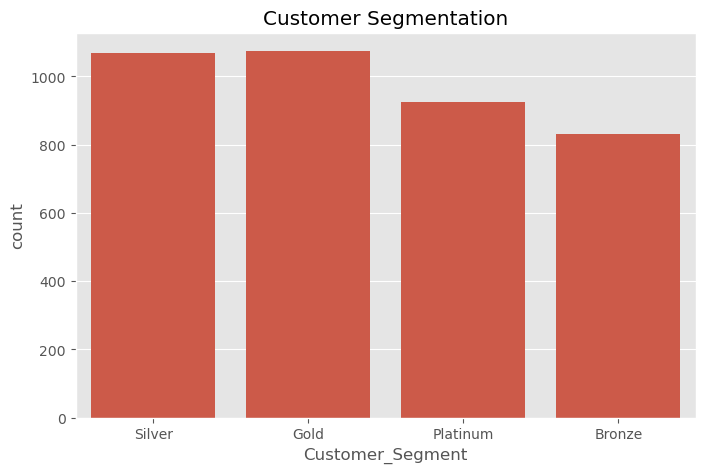

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Customer_Segment",
    data=df
)

plt.title(
    "Customer Segmentation"
)

plt.show()

In [17]:
df["CLV"] = (
    df["Purchase Amount (USD)"] *
    (df["Previous Purchases"] + 1)
)

df[[
    "Customer ID",
    "Purchase Amount (USD)",
    "Previous Purchases",
    "CLV"
]].head()


,Customer ID,Purchase Amount (USD),Previous Purchases,CLV
0,1,53,14,795
1,2,64,2,192
2,3,73,23,1752
3,4,90,49,4500
4,5,49,31,1568


In [18]:
top_customers = (
    df.groupby("Customer ID")["CLV"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer ID
456     5100
993     5049
1848    5000
1738    4998
3747    4950
886     4950
2272    4950
2485    4947
2230    4947
96      4900
Name: CLV, dtype: int64

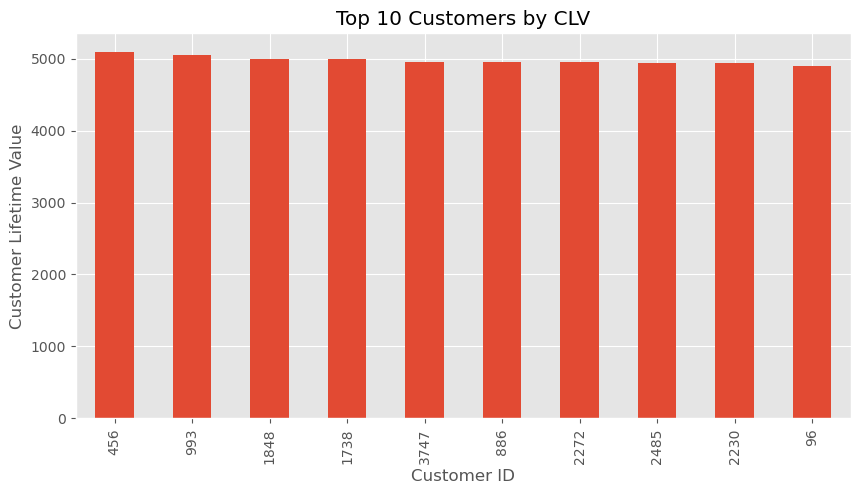

In [19]:
plt.figure(figsize=(10,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by CLV")
plt.ylabel("Customer Lifetime Value")

plt.show()

In [20]:
avg_purchase = df["Purchase Amount (USD)"].mean()

df["Premium_Buyer"] = np.where(
    df["Purchase Amount (USD)"] > avg_purchase,
    "Yes",
    "No"
)

df["Premium_Buyer"].value_counts()

Premium_Buyer
Yes    1963
No     1937
Name: count, dtype: int64

In [21]:
discount_analysis = (
    df.groupby("Discount Applied")
      ["Purchase Amount (USD)"]
      .mean()
)

discount_analysis

Discount Applied
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64

In [22]:
season_revenue = (
    df.groupby("Season")
      ["Purchase Amount (USD)"]
      .sum()
)

season_revenue

Season
Fall      60018
Spring    58679
Summer    55777
Winter    58607
Name: Purchase Amount (USD), dtype: int64

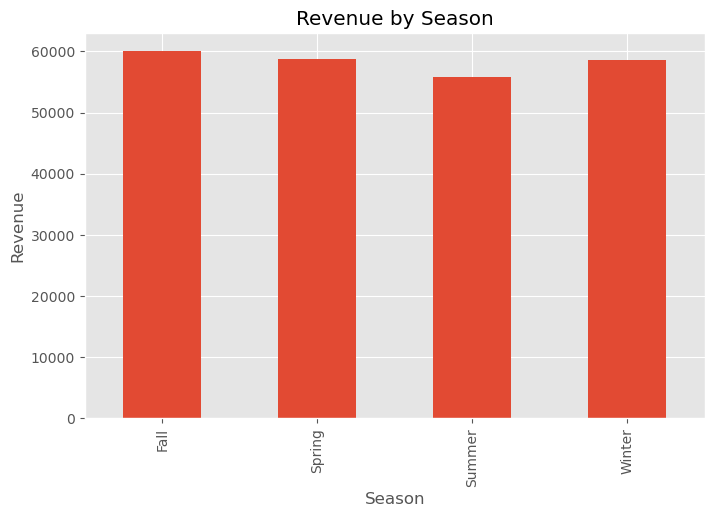

In [23]:
plt.figure(figsize=(8,5))

season_revenue.plot(kind="bar")

plt.title("Revenue by Season")
plt.ylabel("Revenue")

plt.show()

In [24]:
total_revenue = df["Purchase Amount (USD)"].sum()

print("Total Revenue = $", total_revenue)


Total Revenue = $ 233081


In [25]:
aov = df["Purchase Amount (USD)"].mean()

print("Average Order Value = $", round(aov,2))

Average Order Value = $ 59.76


In [26]:
total_customers = df["Customer ID"].nunique()

print("Total Customers =", total_customers)

Total Customers = 3900


In [27]:
subscription_rate = (
    (df["Subscription Status"]=="Yes")
    .mean()*100
)

print(
    "Subscription Rate =",
    round(subscription_rate,2),
    "%"
)

Subscription Rate = 27.0 %


In [28]:
def customer_persona(row):

    if row["Loyalty_Score"] >= 30:
        return "Loyal Customer"

    elif row["Purchase Amount (USD)"] >= 80:
        return "Premium Buyer"

    elif row["Discount Applied"] == "Yes":
        return "Bargain Hunter"

    else:
        return "Casual Shopper"


df["Persona"] = df.apply(
    customer_persona,
    axis=1
)

df["Persona"].value_counts()

Persona
Casual Shopper    1392
Loyal Customer     924
Bargain Hunter     816
Premium Buyer      768
Name: count, dtype: int64

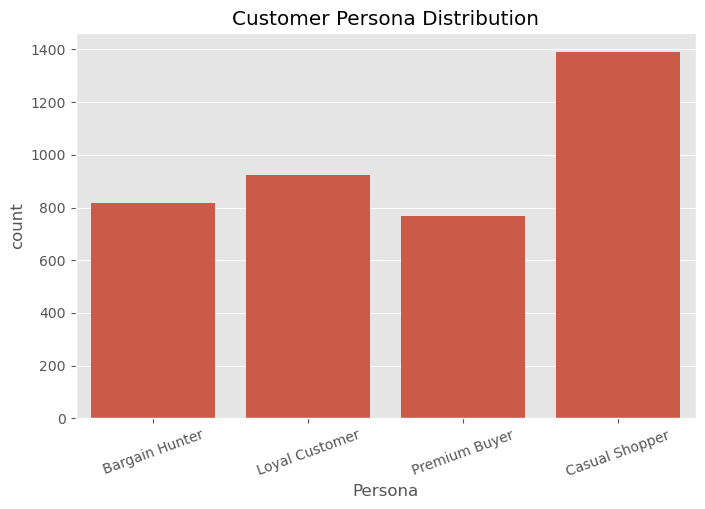

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Persona",
    data=df
)

plt.xticks(rotation=20)

plt.title(
    "Customer Persona Distribution"
)

plt.show()

In [30]:
category_revenue = (
    df.groupby("Category")
      ["Purchase Amount (USD)"]
      .sum()
      .sort_values(
          ascending=False
      )
)

category_revenue

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

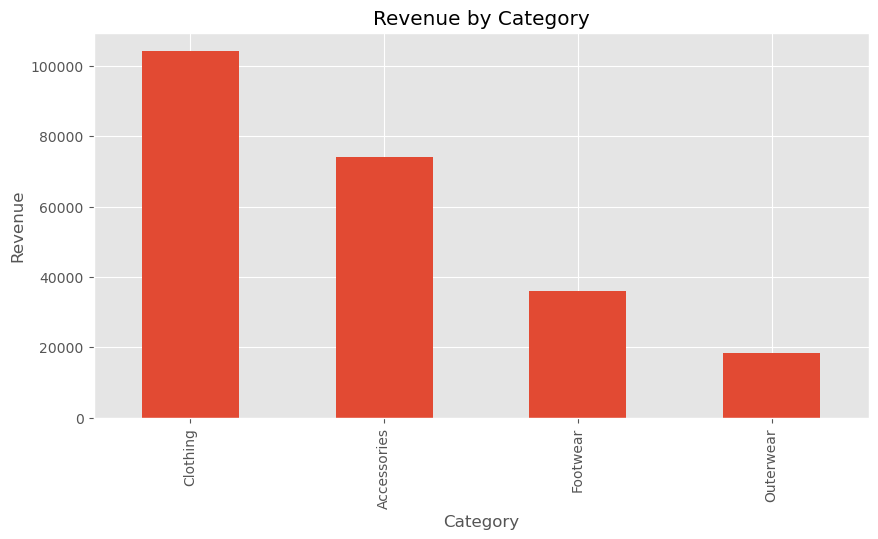

In [31]:
plt.figure(figsize=(10,5))

category_revenue.plot(
    kind="bar"
)

plt.title(
    "Revenue by Category"
)

plt.ylabel("Revenue")

plt.show()

In [32]:
top_products = (
    df.groupby("Item Purchased")
      ["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Item Purchased
Blouse        10410
Shirt         10332
Dress         10320
Pants         10090
Jewelry       10010
Sunglasses     9649
Belt           9635
Scarf          9561
Sweater        9462
Shorts         9433
Name: Purchase Amount (USD), dtype: int64

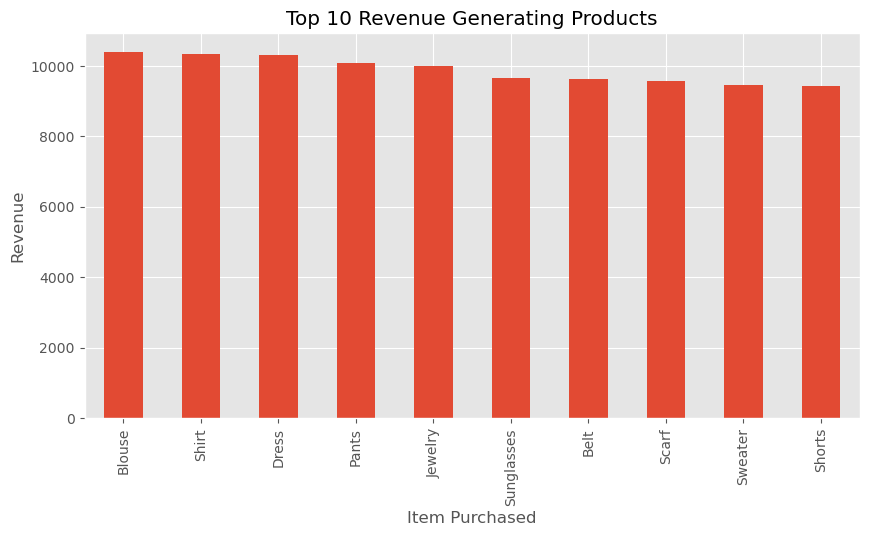

In [33]:
plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Revenue Generating Products")
plt.ylabel("Revenue")

plt.show()

In [34]:
product_rating = (
    df.groupby("Item Purchased")
      ["Review Rating"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

product_rating

Item Purchased
Gloves     3.862774
Sandals    3.844654
Boots      3.818881
Hat        3.801307
Skirt      3.785350
T-shirt    3.779310
Handbag    3.775163
Belt       3.763522
Jacket     3.763190
Sweater    3.760870
Name: Review Rating, dtype: float64

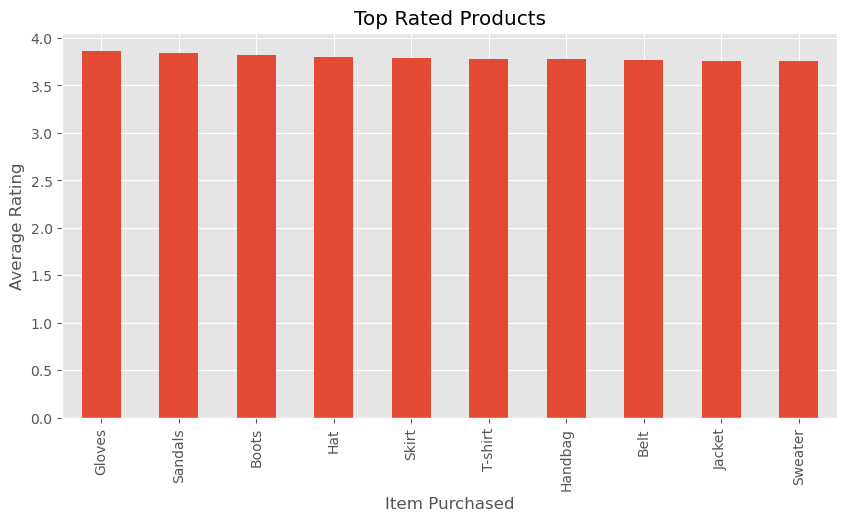

In [35]:
plt.figure(figsize=(10,5))

product_rating.plot(kind="bar")

plt.title("Top Rated Products")

plt.ylabel("Average Rating")

plt.show()

In [36]:
payment_revenue = (
    df.groupby("Payment Method")
      ["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

payment_revenue

Payment Method
Credit Card      40310
PayPal           40109
Cash             40002
Debit Card       38742
Venmo            37374
Bank Transfer    36544
Name: Purchase Amount (USD), dtype: int64

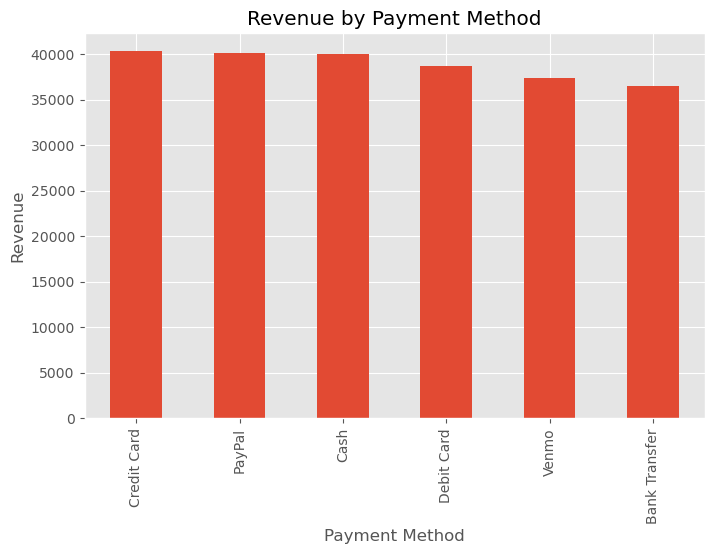

In [37]:
plt.figure(figsize=(8,5))

payment_revenue.plot(kind="bar")

plt.title(
    "Revenue by Payment Method"
)

plt.ylabel("Revenue")

plt.show()

In [38]:
print("="*40)

print(
    "TOTAL REVENUE : $",
    df["Purchase Amount (USD)"].sum()
)

print(
    "TOTAL CUSTOMERS :",
    df["Customer ID"].nunique()
)

print(
    "AVERAGE ORDER VALUE : $",
    round(
        df["Purchase Amount (USD)"].mean(),
        2
    )
)

print(
    "AVG REVIEW RATING :",
    round(
        df["Review Rating"].mean(),
        2
    )
)

print("="*40)

TOTAL REVENUE : $ 233081
TOTAL CUSTOMERS : 3900
AVERAGE ORDER VALUE : $ 59.76
AVG REVIEW RATING : 3.75
